Project Title - Ola Ride Insights

Read the data using Pandas

In [ ]:
import pandas as pd
df = pd.read_excel(r"\Users\dhuma\OneDrive\Desktop\GUVI\Project_2\Current\OLA_DataSet.xlsx")

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        103024 non-null  datetime64[us]
 1   Time                        103024 non-null  object        
 2   Booking_ID                  103024 non-null  str           
 3   Booking_Status              103024 non-null  str           
 4   Customer_ID                 103024 non-null  str           
 5   Vehicle_Type                103024 non-null  str           
 6   Pickup_Location             103024 non-null  str           
 7   Drop_Location               103024 non-null  str           
 8   V_TAT                       63967 non-null   float64       
 9   C_TAT                       63967 non-null   float64       
 10  Canceled_Rides_by_Customer  10499 non-null   str           
 11  Canceled_Rides_by_Driver    18434 non-null   str  

Check if any missing values

In [36]:
df.isnull().sum()

Date                              0
Time                              0
Booking_ID                        0
Booking_Status                    0
Customer_ID                       0
Vehicle_Type                      0
Pickup_Location                   0
Drop_Location                     0
V_TAT                         39057
C_TAT                         39057
Canceled_Rides_by_Customer    92525
Canceled_Rides_by_Driver      84590
Incomplete_Rides              39057
Incomplete_Rides_Reason       99098
Booking_Value                     0
Payment_Method                39057
Ride_Distance                     0
Driver_Ratings                39057
Customer_Rating               39057
Vehicle Images                    0
dtype: int64

Calculate missing percentage

In [37]:
df.isnull().sum()/len(df)*100

Date                           0.000000
Time                           0.000000
Booking_ID                     0.000000
Booking_Status                 0.000000
Customer_ID                    0.000000
Vehicle_Type                   0.000000
Pickup_Location                0.000000
Drop_Location                  0.000000
V_TAT                         37.910584
C_TAT                         37.910584
Canceled_Rides_by_Customer    89.809171
Canceled_Rides_by_Driver      82.107082
Incomplete_Rides              37.910584
Incomplete_Rides_Reason       96.189237
Booking_Value                  0.000000
Payment_Method                37.910584
Ride_Distance                  0.000000
Driver_Ratings                37.910584
Customer_Rating               37.910584
Vehicle Images                 0.000000
dtype: float64

Check if any duplicate rows

In [38]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
103019    False
103020    False
103021    False
103022    False
103023    False
Length: 103024, dtype: bool

Count duplicate rows

In [39]:
df.duplicated().sum()

np.int64(0)

Replaces all NaN values with 0 for Numerical columns

In [40]:
df = df.fillna({'V_TAT': 0, 'C_TAT': 0,'Driver_Ratings':0,'Customer_Rating':0})

Converting categorical columns datatype into object, reason behind to change datatype -> MySQL database doesn't support NaN values, however, it interpret 'None' value as null,so in this way, it will be easy to insert data into MySQL

by using fillna() method will replace NaN values with None.

In [41]:

df = df.astype({'Canceled_Rides_by_Customer': object, 'Canceled_Rides_by_Driver': object, 
                'Incomplete_Rides': object,'Incomplete_Rides_Reason': object,'Payment_Method':object})


In [42]:
# Replaces all NaN values with None for Categorical columns
df = df.fillna({'Canceled_Rides_by_Customer': None, 'Canceled_Rides_by_Driver': None,'Incomplete_Rides':None,
                'Incomplete_Rides_Reason':None,'Payment_Method':None})

Extracting only the date value from column 'Date', which contains date & time together,however we already have separate 'Time' column. 

In [43]:
df['Date'] = pd.to_datetime(df['Date']).dt.date

In [44]:
df.head(5)

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images
0,2024-07-26,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,0.0,0.0,None,Personal & Car related issue,None,None,444,None,0,0.0,0.0,https://cdn-icons-png.flaticon.com/128/14183/1...
1,2024-07-25,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,None,None,No,None,158,Cash,13,4.1,4.0,https://cdn-icons-png.flaticon.com/128/9983/99...
2,2024-07-30,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,None,None,No,None,386,UPI,40,4.2,4.8,https://cdn-icons-png.flaticon.com/128/9983/99...
3,2024-07-22,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,0.0,0.0,Driver is not moving towards pickup location,None,None,None,384,None,0,0.0,0.0,https://cdn-icons-png.flaticon.com/128/6839/68...
4,2024-07-02,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,None,None,No,None,822,Credit Card,45,4.0,3.0,https://cdn-icons-png.flaticon.com/128/3202/32...


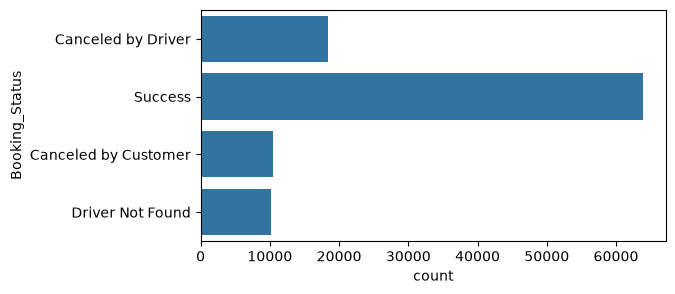

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,3))
sns.countplot(df['Booking_Status'])
plt.show()

As per above count plot we analysed more than 60+K are successful bookings.

Counts the frequency of unique values of 'Vehicle_Type' column

In [46]:
df['Vehicle_Type'].value_counts()

Vehicle_Type
Prime Sedan    14877
eBike          14816
Auto           14755
Prime Plus     14707
Bike           14662
Prime SUV      14655
Mini           14552
Name: count, dtype: int64

Counts the frequency of unique values of 'Canceled_Rides_by_Customer' column

In [47]:
df['Canceled_Rides_by_Customer'].value_counts()

Canceled_Rides_by_Customer
Driver is not moving towards pickup location    3175
Driver asked to cancel                          2670
Change of plans                                 2081
AC is Not working                               1568
Wrong Address                                   1005
Name: count, dtype: int64

calculates the frequency of each unique value in column "Canceled_Rides_by_Customer" and visualizes that distribution as a pie chart with percentage labels

<Axes: >

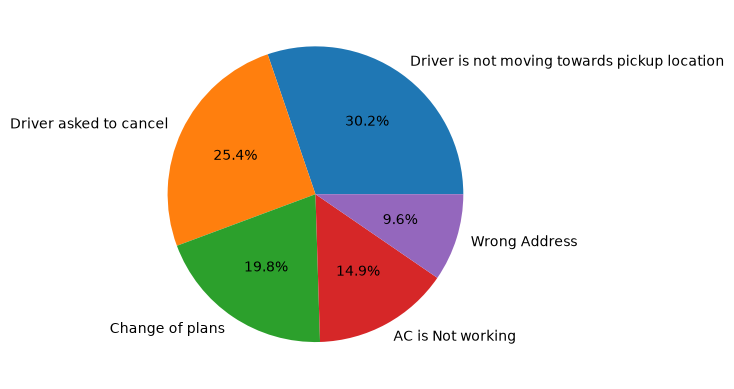

In [48]:
df['Canceled_Rides_by_Customer'].value_counts().plot.pie(autopct='%1.1f%%')

Counts the frequency of unique values of 'Canceled_Rides_by_Driver' column

In [49]:
df['Canceled_Rides_by_Driver'].value_counts()

Canceled_Rides_by_Driver
Personal & Car related issue           6542
Customer related issue                 5413
Customer was coughing/sick             3654
More than permitted people in there    2825
Name: count, dtype: int64

calculates the frequency of each unique value in column "Canceled_Rides_by_Driver" and visualizes that distribution as a pie chart with percentage labels

<Axes: >

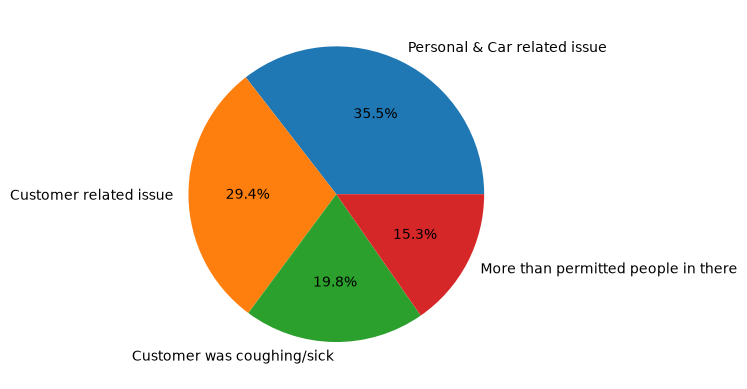

In [50]:
df['Canceled_Rides_by_Driver'].value_counts().plot.pie(autopct='%1.1f%%')

In [53]:
# Final Verification 
print("\n--- Verification ---")
print("Missing values in dataset:", df.isnull().sum().sum())

print("\nCleaned DataFrame Info:")
df.info()


--- Verification ---
Missing values in dataset: 354327

Cleaned DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Date                        103024 non-null  object 
 1   Time                        103024 non-null  object 
 2   Booking_ID                  103024 non-null  str    
 3   Booking_Status              103024 non-null  str    
 4   Customer_ID                 103024 non-null  str    
 5   Vehicle_Type                103024 non-null  str    
 6   Pickup_Location             103024 non-null  str    
 7   Drop_Location               103024 non-null  str    
 8   V_TAT                       103024 non-null  float64
 9   C_TAT                       103024 non-null  float64
 10  Canceled_Rides_by_Customer  10499 non-null   object 
 11  Canceled_Rides_by_Driver    18434 non-null   object 
 12  In

In [ ]:
# Save the Cleaned Data 
cleaned_file_path = 'final_cleaned_data.csv'
print(f"\nSaving cleaned data to '{cleaned_file_path}'...")
df.to_csv(cleaned_file_path, index=False)
print("Cleaned data saved successfully!")


Saving cleaned data to 'ola_ride_dataset.csv'...
Cleaned data saved successfully!


Creating MySQL connection

In [62]:
import mysql.connector
connection = mysql.connector.connect(
    host = "localhost",
    user = "root",
    password = "12345678"
)
cursor = connection.cursor()
cursor
print('MySQL connection established')

MySQL connection established


Create a Database in MySQL
Once we've established an SQL connection, we need to create a database to store our traffic crash data.

In [2]:

cursor.execute("Create database ola_db;")
print('Database ola_db created successfully!')

Database ola_db created successfully!


Create Table in MySQL

In [63]:
cursor.execute("USE ola_db;")

In [ ]:
query = '''CREATE table ola_ride_data (Date date,
                                    Time time,
                                    Booking_ID varchar(50),
                                    Booking_Status varchar(50),
                                    Customer_ID varchar(50),
                                    Vehicle_Type varchar(50),
                                    Pickup_Location text,
                                    Drop_Location text,
                                    V_TAT float,
                                    C_TAT float,
                                    Canceled_Rides_by_Customer text,
                                    Canceled_Rides_by_Driver text,
                                    Incomplete_Rides text,
                                    Incomplete_Rides_Reason text,
                                    Booking_Value int,
                                    Payment_Method varchar(50),
                                    Ride_Distance int,
                                    Driver_Ratings float,
                                    Customer_Rating float,
                                    Vehicle_Images text
                                );'''
cursor.execute(query)
connection.commit()
print("Table 'ola_ride_data' created successfully in MySQL")

Table 'ola_ride_data' created successfully in MySQL


Insert the data FROM DataFrame into MySQL.
Now, we'll insert data from the Pandas DataFrame into the MySQL table.

In [52]:
query = '''INSERT into ola_ride_data (Date,
                                      Time,
                                      Booking_ID,
                                      Booking_Status,
                                      Customer_ID,
                                      Vehicle_Type,
                                      Pickup_Location,
                                      Drop_Location,
                                      V_TAT,
                                      C_TAT,
                                      Canceled_Rides_by_Customer,
                                      Canceled_Rides_by_Driver,
                                      Incomplete_Rides,
                                      Incomplete_Rides_Reason,
                                      Booking_Value,
                                      Payment_Method,
                                      Ride_Distance,
                                      Driver_Ratings,
                                      Customer_Rating,
                                      Vehicle_Images
                                ) VALUES(%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)'''
for row in df.itertuples():
    cursor.execute(query,(row[1],row[2],row[3],row[4],row[5],row[6],row[7],row[8],row[9],row[10],row[11],row[12],row[13],row[14],row[15],row[16],row[17],row[18],row[19],row[20]))
    
connection.commit()
print("Data inserted successfully")

Data inserted successfully


Running SQL Queries

1. Retrieve all successful bookings:

In [ ]:
cursor.execute("SELECT * FROM ola_ride_data WHERE Booking_Status = 'Success';")
connection.commit()

InternalError: Unread result found

2. Find the average ride distance for each vehicle type:

In [ ]:
cursor.execute('''
              SELECT 
		    Vehicle_Type, 
		    ROUND(AVG(Ride_Distance),2) as avg_distance 
              FROM 
	           ola_ride_data
              WHERE
		    Booking_Status = 'success'
              GROUP BY 
                  Vehicle_Type
              ORDER BY
                  avg_distance DESC;''')
connection.commit()

InternalError: Unread result found

3. Get the total number of cancelled rides by customers:

In [ ]:
cursor.execute(''' SELECT COUNT(*) FROM ola_ride_data WHERE Booking_Status = 'Canceled by Customer';''')
connection.commit()

4. List the top 5 customers who booked the highest number of rides:

In [ ]:
cursor.execute('''
                 SELECT 
		       Customer_ID, 
		       COUNT(Booking_ID) as total_rides 
                 FROM 
                     ola_ride_data 
                 GROUP BY 
                     Customer_ID 
                 ORDER BY 
                     total_rides DESC 
                 LIMIT 5;''')
connection.commit()

#5. Get the number of rides cancelled by drivers due to personal and car-related issues:

In [ ]:
cursor.execute('''
                SELECT 
                    COUNT(*) 
                FROM 
                    ola_ride_data 
                WHERE 
		            Canceled_Rides_by_Driver = 'Personal & Car related issue';''')
connection.commit()

6. Find the maximum and minimum driver ratings for Prime Sedan bookings:

In [ ]:
cursor.execute(''' 
                SELECT 
                    MAX(Driver_Ratings) as max_rating, 
		      MIN(Driver_Ratings) as min_rating 
                FROM 
                    ola_ride_data 
                WHERE 
                    Vehicle_Type = 'Prime Sedan' AND  Booking_Status = 'success';''')
connection.commit()

7. Retrieve all rides where payment was made using UPI:

In [ ]:
cursor.execute('SELECT * FROM ola_ride_data WHERE Payment_Method = 'UPI';')
connection.commit()

8. Find the average customer rating per vehicle type:

In [ ]:
cursor.execute('''
                SELECT 
		      Vehicle_Type, 
		      ROUND(AVG(Customer_Rating),2) as avg_customer_rating 
                FROM 
		      ola_ride_data
                WHERE
		      Booking_Status = 'success' AND Customer_Rating > 0
                GROUP BY
                    Vehicle_Type
                ORDER BY
                    avg_customer_rating DESC; ''')
connection.commit()

9. Calculate the total booking value of rides completed successfully:

In [ ]:
cursor.execute('''
                SELECT 
                    SUM(Booking_Value) as total_successful_value 
                FROM 
                    ola_ride_data 
                WHERE 
                    Booking_Status = 'Success';''')
connection.commit()

10. List all incomplete rides along with the reason

In [ ]:
cursor.execute('''
                SELECT 
                    Booking_ID, 
                    Booking_Status,
                    Vehicle_Type,
                    Pickup_Location,
                    Drop_Location,
		            Incomplete_Rides_Reason 
                FROM 
                    ola_ride_data 
                WHERE 
                    Incomplete_Rides ='Yes';''')
connection.commit()